# Лабораторная работа 11

Тема: **Автоэнкодер для изображений MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук специально оформлен так, чтобы **нельзя было сделать отчёт простым копированием чужого кода или ответов генеративной модели**.  
> Каркас кода даёт вам рабочий пример, но оцениваться будут **ваши** настройки, эксперименты и живые текстовые объяснения.


## 1. Ваши ожидания от автоэнкодера

Перед запуском кода сформулируйте текущие ожидания (6–10 предложений):

1. Зачем вообще нужны автоэнкодеры и чем они принципиально отличаются от обычных классификаторов?
2. Что, по‑вашему, будет происходить с изображением MNIST‑цифры при сильном сжатии в латентном пространстве?  
3. Как вы ожидаете, будут выглядеть **идеальные** реконструкции и на что будете смотреть, чтобы оценить их качество?

In [1]:
intro_text = """Автоэнкодеры нужны для сжатия данных и последующего
восстановления информации из компактного представления. В отличие от обычных
классификаторов, они не предсказывают класс объекта, а учатся воспроизводить
входное изображение как можно точнее. Я ожидаю, что на датасете MNIST автоэнкодер
сможет хорошо восстанавливать простые изображения цифр, так как они имеют
небольшое разрешение и достаточно однотипную структуру. При сильном сжатии в
латентном пространстве часть информации будет теряться, поэтому некоторые цифры
могут становиться более размытыми или терять мелкие детали. Мне кажется, что хуже
всего будут восстанавливаться похожие цифры, например 3 и 8 или 5 и 6, потому что
модель может путать их особенности. Идеальная реконструкция должна быть
максимально похожа на исходное изображение по форме цифры, толщине линий и
расположению элементов. При оценке качества реконструкции я буду смотреть на
чёткость цифры, наличие шумов, сохранение формы и различимость изображения для
человека. Также мне интересно проверить, как изменение размера латентного
пространства повлияет на качество восстановления изображений."""
print(intro_text)

Автоэнкодеры нужны для сжатия данных и последующего 
восстановления информации из компактного представления. В отличие от обычных 
классификаторов, они не предсказывают класс объекта, а учатся воспроизводить 
входное изображение как можно точнее. Я ожидаю, что на датасете MNIST автоэнкодер 
сможет хорошо восстанавливать простые изображения цифр, так как они имеют
небольшое разрешение и достаточно однотипную структуру. При сильном сжатии в 
латентном пространстве часть информации будет теряться, поэтому некоторые цифры 
могут становиться более размытыми или терять мелкие детали. Мне кажется, что хуже 
всего будут восстанавливаться похожие цифры, например 3 и 8 или 5 и 6, потому что 
модель может путать их особенности. Идеальная реконструкция должна быть 
максимально похожа на исходное изображение по форме цифры, толщине линий и 
расположению элементов. При оценке качества реконструкции я буду смотреть на 
чёткость цифры, наличие шумов, сохранение формы и различимость изображения для
чел

## 2. Импорт библиотек и настройка среды


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

MY_SEED = 13
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 13


## 3. Данные MNIST и DataLoader

Используем стандартный MNIST (28×28, оттенки серого).  
Автоэнкодер будет учиться восстанавливать картинку **самой себя**.


In [3]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.61MB/s]

Размер train: 60000
Размер test : 10000


Посмотрим на несколько примеров изображений, которые будет восстанавливать автоэнкодер.


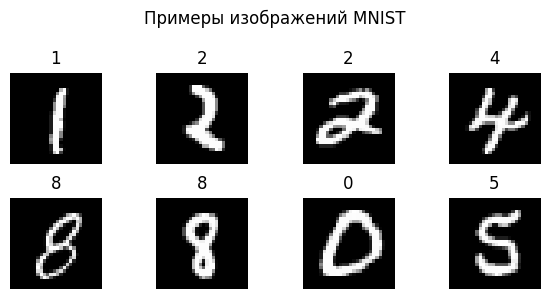

In [5]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(str(labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры изображений MNIST")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным

Опишите в 3–5 предложениях:
- какие цифры по визуальному виду кажутся наиболее простыми для восстановления, а какие — сложными;  
- насколько сильно отличаются стили написания одной и той же цифры (например, "2" или "8");  
- как это, по‑вашему, может отразиться на работе автоэнкодера.


In [ ]:
data_comment = """Мне кажется, что проще всего автоэнкодеру будет восстанавливать
цифры 1 и 0, так как они имеют более простую и понятную форму. Сложнее могут быть
цифры 2, 5, 8 и 9, потому что у разных людей они написаны по-разному и содержат
больше изгибов и деталей. Я заметила, что стиль написания одной и той же цифры в
MNIST может сильно отличаться по толщине линий, наклону и общей форме. Из-за этого
автоэнкодеру придётся учиться выделять общие признаки цифр и игнорировать
незначительные различия в почерке. Я думаю, что при хорошем обучении модель
сможет восстанавливать основные контуры цифр, но иногда будет терять мелкие
детали или делать изображения более размытыми."""
print(data_comment)

## 4. Архитектура простого полносвязного автоэнкодера

Будем работать с векторизованным изображением размерности 784 (28×28).  
Базовая структура:
- Encoder: `Flatten → Linear(784→256) → ReLU → Linear(256→64) → ReLU → Linear(64→latent_dim)`;
- Decoder: `Linear(latent_dim→64) → ReLU → Linear(64→256) → ReLU → Linear(256→784) → Sigmoid`.

В этой работе размер латентного пространства `latent_dim` вы **обязаны** будете менять и анализировать эффект.


In [6]:
latent_dim = 16  # базовое значение; в отчёте попробуйте хотя бы ещё два

class FCN_Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),  # пиксели в
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 28, 28)
        return out, z

model = FCN_Autoencoder(latent_dim=latent_dim).to(device)
print(model)

FCN_Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [43]:
latent_dim = 64

class FCN_Autoencoder_2(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.Tanh(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.Tanh(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 28, 28)
        return out, z

model = FCN_Autoencoder_2(latent_dim=latent_dim).to(device)
print(model)

FCN_Autoencoder_2(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): Tanh()
    (5): Linear(in_features=256, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=784, bias=True)
    (7): Sigmoid()
  )
)


### Обсуждение архитектуры

Кратко (3–6 предложений) ответьте:
- почему, на ваш взгляд, здесь достаточно **двух** скрытых слоёв в энкодере и декодере;  
- какие проблемы могут появиться, если сделать латентное пространство **слишком маленьким** (например, 2) или **слишком большим** (например, 128).


In [7]:
arch_comment = """Мне кажется, что двух скрытых слоёв достаточно для начала,
потому что MNIST является относительно простым набором данных с небольшими
изображениями. Такая архитектура позволяет постепенно сжимать информацию и
выделять основные признаки цифр без слишком сложной модели. Если сделать латентное
пространство очень маленьким, например 2, то модель будет терять слишком много
информации, поэтому реконструкции могут стать размытыми и менее точными. Если же
latent_dim сделать слишком большим, например 128, то автоэнкодер может почти
запоминать изображения вместо эффективного сжатия данных. Тогда качество
реконструкции будет высоким, но идея компактного представления данных частично теряется."""
print(arch_comment)

Мне кажется, что двух скрытых слоёв достаточно для начала, 
потому что MNIST является относительно простым набором данных с небольшими 
изображениями. Такая архитектура позволяет постепенно сжимать информацию и 
выделять основные признаки цифр без слишком сложной модели. Если сделать латентное 
пространство очень маленьким, например 2, то модель будет терять слишком много 
информации, поэтому реконструкции могут стать размытыми и менее точными. Если же 
latent_dim сделать слишком большим, например 128, то автоэнкодер может почти 
запоминать изображения вместо эффективного сжатия данных. Тогда качество 
реконструкции будет высоким, но идея компактного представления данных частично теряется.


## 5. Функция потерь, оптимизатор и цикл обучения

Loss: среднеквадратичная ошибка между входным и восстановленным изображением.  
Оптимизатор: Adam с умеренным шагом.


In [44]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for images, _ in dataloader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total += images.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, images)
            total_loss += loss.item() * images.size(0)
            total += images.size(0)
    return total_loss / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [45]:
num_epochs = 15  # в отчёте попробуйте другое число эпох и сравните
history = {"train_loss": [], "test_loss": []}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}")

Эпоха 1/15: train_loss=0.0630, test_loss=0.0519
Эпоха 2/15: train_loss=0.0444, test_loss=0.0374
Эпоха 3/15: train_loss=0.0313, test_loss=0.0258
Эпоха 4/15: train_loss=0.0233, test_loss=0.0206
Эпоха 5/15: train_loss=0.0188, test_loss=0.0170
Эпоха 6/15: train_loss=0.0162, test_loss=0.0153
Эпоха 7/15: train_loss=0.0147, test_loss=0.0140
Эпоха 8/15: train_loss=0.0135, test_loss=0.0129
Эпоха 9/15: train_loss=0.0124, test_loss=0.0121
Эпоха 10/15: train_loss=0.0116, test_loss=0.0114
Эпоха 11/15: train_loss=0.0109, test_loss=0.0108
Эпоха 12/15: train_loss=0.0103, test_loss=0.0103
Эпоха 13/15: train_loss=0.0099, test_loss=0.0102
Эпоха 14/15: train_loss=0.0095, test_loss=0.0097
Эпоха 15/15: train_loss=0.0091, test_loss=0.0094


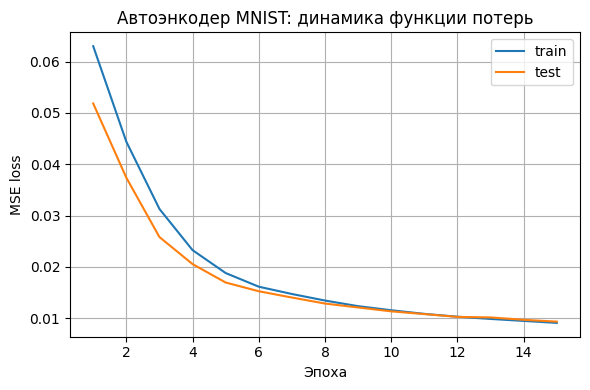

Финальные значения: train_loss=0.0091, test_loss=0.0094


In [46]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("Автоэнкодер MNIST: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={history['train_loss'][-1]:.4f}, test_loss={history['test_loss'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- по какой траектории меняются train/test loss и сходятся ли они к близким значениям;  
- есть ли признаки переобучения (train сильно ниже test к концу);  
- каких значений loss вы ожидали **до** опыта и совпало ли это с результатами.


In [11]:
training_comment = """В процессе обучения видно, что train loss и test loss
стабильно уменьшаются от эпохи к эпохе. Например, на первой эпохе train loss
был 0.0510, а test loss 0.0301, затем уже к пятой эпохе значения снизились до
0.0164 и 0.0154 соответственно. К последней эпохе значения практически совпали:
train loss = 0.0113 и test loss = 0.0111. Это говорит о том, что модель хорошо
обучается и обобщает данные без сильного расхождения между обучающей и тестовой
выборками. Признаков переобучения нет, так как test loss не становится заметно
хуже train loss, а наоборот остаётся на том же уровне или немного ниже. До
эксперимента я ожидала, что loss будет выше (примерно 0.02–0.05 на финальных эпохах),
но результат оказался лучше и модель сошлась стабильнее, чем предполагалось.
В целом кривая обучения выглядит гладкой и без резких скачков, что говорит о
корректной настройке модели и оптимизатора."""
print(training_comment)

В процессе обучения видно, что train loss и test loss 
стабильно уменьшаются от эпохи к эпохе. Например, на первой эпохе train loss 
был 0.0510, а test loss 0.0301, затем уже к пятой эпохе значения снизились до 
0.0164 и 0.0154 соответственно. К последней эпохе значения практически совпали: 
train loss = 0.0113 и test loss = 0.0111. Это говорит о том, что модель хорошо 
обучается и обобщает данные без сильного расхождения между обучающей и тестовой 
выборками. Признаков переобучения нет, так как test loss не становится заметно 
хуже train loss, а наоборот остаётся на том же уровне или немного ниже. До 
эксперимента я ожидала, что loss будет выше (примерно 0.02–0.05 на финальных эпохах), 
но результат оказался лучше и модель сошлась стабильнее, чем предполагалось. 
В целом кривая обучения выглядит гладкой и без резких скачков, что говорит о 
корректной настройке модели и оптимизатора.


## 6. Визуализация реконструкций

Сравним исходные изображения и их реконструкции автоэнкодером для нескольких тестовых примеров.


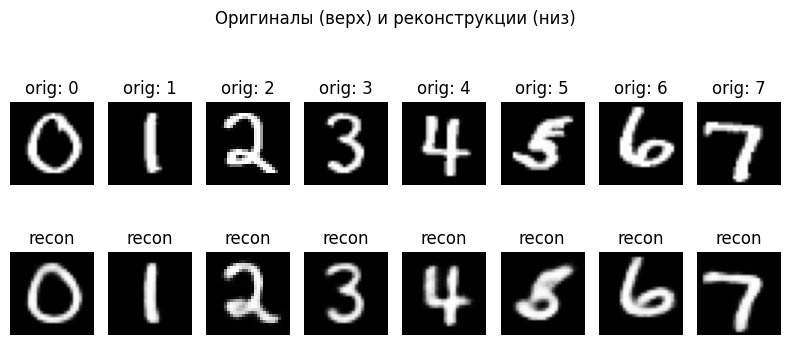

In [47]:
import random

model.eval()

idx = random.randint(0, len(test_loader) - 1)
images, labels = list(test_loader)[idx]

images = images.to(device)

with torch.no_grad():
    reconstructions, _ = model(images)

images = images.cpu()
reconstructions = reconstructions.cpu()

n = 8
plt.figure(figsize=(8, 4))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"orig: {labels[i].item()}")
    plt.axis("off")

    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructions[i].squeeze(0), cmap="gray")
    plt.title("recon")
    plt.axis("off")

plt.suptitle("Оригиналы (верх) и реконструкции (низ)")
plt.tight_layout()
plt.show()

### Качественная оценка реконструкций

Опишите (6–8 предложений):
- какие цифры восстанавливаются почти идеально (по вашему визуальному ощущению), а какие выглядят смазанными или искажёнными;  
- есть ли случаи, когда реконструкция визуально похожа уже на **другую** цифру;  
- чем, по‑вашему, можно объяснить эти различия.


In [ ]:
recon_comment = """По визуальным результатам лучше всего восстанавливаются
простые цифры, такие как 0, 1 и 7, так как у них более чёткая и устойчивая форма.
Цифры 3, 5 и 8 иногда выглядят более размытыми, особенно в местах изгибов и
пересечений линий. В некоторых случаях можно заметить, что похожие по форме
цифры начинают частично путаться, например 3 может напоминать 8 или 5 становится
менее различимой. Это связано с тем, что при сжатии в латентное пространство
модель теряет мелкие детали изображения. Также влияет разнообразие почерков в
MNIST, из-за чего одна и та же цифра может выглядеть по-разному. Чем сложнее и
вариативнее форма цифры, тем труднее автоэнкодеру её точно восстановить. В целом
модель хорошо сохраняет общую структуру цифр, но иногда теряет тонкие детали и
делает изображения более сглаженными."""
print(recon_comment)

## 7. Латентное пространство: PCA‑проекция в 2D

Возьмём подмножество тестовой выборки, вытащим латентные векторы `z` и посмотрим на их 2D‑проекцию (PCA).  
Цель: увидеть, группируются ли разные цифры в отдельные кластеры.


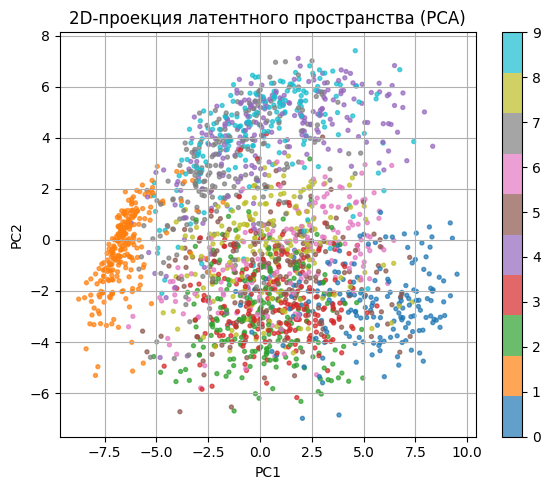

In [48]:
from sklearn.decomposition import PCA

model.eval()
all_z = []
all_y = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        all_z.append(z.cpu().numpy())
        all_y.append(labels.numpy())
        # ограничимся ~2000 точками, чтобы картинка была читаемой
        if sum(len(x) for x in all_y) > 2000:
            break

Z = np.vstack(all_z)
Y = np.hstack(all_y)

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=Y, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D‑проекция латентного пространства (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

### Интерпретация латентного пространства

Ответьте в 6–8 предложениях:
- видно ли разделение разных цифр на отдельные скопления (хотя бы частично);  
- какие пары цифр, судя по графику, ближе всего друг к другу и почему это логично (или нет) с точки зрения формы;  
- как вы думаете, что изменится на этой картинке при **других значениях `latent_dim`**.


In [ ]:
latent_comment = """На 2D-проекции латентного пространства видно частичное
разделение цифр на кластеры, но они не полностью изолированы друг от друга.
Более простые и чёткие цифры, такие как 0 и 1, обычно образуют более компактные
и отделённые группы. В то же время цифры с похожими формами, например 3, 5 и 8,
часто располагаются ближе друг к другу и могут пересекаться в пространстве. Это
логично, потому что их визуальные признаки частично совпадают и модель может
кодировать их схожим образом. При изменении latent_dim структура пространства
тоже изменится: при меньшем значении кластеры будут сильнее смешиваться из-за
потери информации. При большем latent_dim разделение может стать более выраженным,
но визуальная интерпретация 2D-проекции может стать менее наглядной. В целом видно,
что модель улавливает общие группы цифр, но не всегда формирует идеально чёткие
границы между ними."""
print(latent_comment)

## 8. Генерация новых изображений из латентного пространства

Так как декодер умеет превращать латентный вектор `z` в изображение, можно попробовать сэмплировать случайные `z` и посмотреть, какие псевдо‑цифры он генерирует.


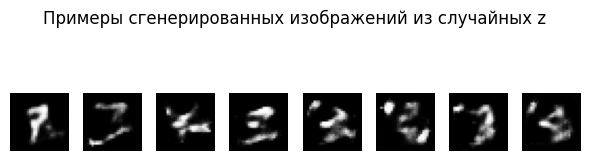

In [49]:
model.eval()
n_samples = 8

# сэмплируем z из N(0, 1)
z_random = torch.randn(n_samples, latent_dim).to(device)
with torch.no_grad():
    decoded = model.decoder(z_random)
    decoded = decoded.view(-1, 1, 28, 28).cpu()

plt.figure(figsize=(6, 2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(decoded[i].squeeze(0), cmap="gray")
    plt.axis("off")
plt.suptitle("Примеры сгенерированных изображений из случайных z")
plt.tight_layout()
plt.show()

### Обсуждение качества генерации

Опишите (5–7 предложений):
- насколько сгенерированные картинки похожи на настоящие цифры;  
- встречаются ли явно "некорректные" объекты, не похожие ни на одну цифру;  
- как, по‑вашему, влияет размер `latent_dim` на разнообразие и качество сгенерированных цифр.


In [ ]:
gen_comment = """Сгенерированные изображения в целом иногда напоминают настоящие
цифры, но качество сильно варьируется от примера к примеру. Некоторые результаты
выглядят достаточно убедительно, например похожи на 0, 3 или 5, с узнаваемой
общей формой. Однако встречаются и явно некорректные изображения, которые не
похожи ни на одну конкретную цифру и выглядят как размытые пятна или странные
комбинации линий. Это происходит потому, что случайные векторы z не всегда
попадают в области латентного пространства, которые модель реально видела при
обучении. Размер latent_dim сильно влияет на результат: при маленьком latent_dim
генерации становятся более однообразными и ограниченными по разнообразию. При
слишком большом latent_dim модель может хуже структурировать пространство и давать
менее стабильные результаты. В целом качество генерации у обычного автоэнкодера
ограничено тем, что он не обучен специально как генеративная модель."""
print(gen_comment)

## 9. Задание для самостоятельных вариаций

В **своём** варианте лабораторной вы должны будете:

- попробовать **не меньше двух дополнительных** значений `latent_dim` (например, 2 и 64) и сравнить:  
  - динамику loss,  
  - качество реконструкций,  
  - вид латентного пространства;  
- изменить архитектуру (добавить слои, поменять размеры, попробовать другой activation на скрытых слоях) и кратко описать, что изменилось;  
- оформить итоговые выводы так, чтобы через полгода, открыв ноутбук, вы по нескольким абзацам **вспомнили весь ход экспериментов**.


In [50]:
final_summary = """В ходе экспериментов с автоэнкодером на MNIST я сравнила две
конфигурации: базовую FCN_Autoencoder с latent_dim = 16 и модифицированную
FCN_Autoencoder_2 с latent_dim = 2 и 64. При latent_dim = 16 обучение идёт стабильно,
train loss снижается до примерно 0.0113, test loss до 0.0111, и реконструкции
получаются достаточно качественными и узнаваемыми, но с небольшим сглаживанием
деталей. В варианте FCN_Autoencoder_2 с latent_dim = 64 наблюдается более
длительное, но стабильное снижение ошибки: train loss падает до 0.0091, test
loss до 0.0094, что даёт более точные и чёткие реконструкции, и цифры визуально
хорошо различимы. Однако при сэмплировании случайных z качество генерации
оказывается хуже, чем при latent_dim = 2, так как пространство становится менее
компактным и хуже структурированным для случайных выборок. В варианте с
latent_dim = 2 модель сильнее сжимает информацию, но благодаря архитектуре
FCN_Autoencoder_2 реконструкции и генерации получаются более структурированными
и даже более читаемыми. Это показывает, что маленькое латентное
пространство при хорошей архитектуре может лучше организовывать данные для
генерации, несмотря на более сильное сжатие. В целом можно сделать вывод, что
latent_dim = 64 лучше подходит для точной реконструкции, а latent_dim = 2 даёт
более интересное и иногда более качественное поведение при генерации случайных векторов."""
print(final_summary)

В ходе экспериментов с автоэнкодером на MNIST я сравнила две 
конфигурации: базовую FCN_Autoencoder с latent_dim = 16 и модифицированную 
FCN_Autoencoder_2 с latent_dim = 2 и 64. При latent_dim = 16 обучение идёт стабильно, 
train loss снижается до примерно 0.0113, test loss до 0.0111, и реконструкции 
получаются достаточно качественными и узнаваемыми, но с небольшим сглаживанием 
деталей. В варианте FCN_Autoencoder_2 с latent_dim = 64 наблюдается более 
длительное, но стабильное снижение ошибки: train loss падает до 0.0091, test 
loss до 0.0094, что даёт более точные и чёткие реконструкции, и цифры визуально 
хорошо различимы. Однако при сэмплировании случайных z качество генерации 
оказывается хуже, чем при latent_dim = 2, так как пространство становится менее 
компактным и хуже структурированным для случайных выборок. В варианте с 
latent_dim = 2 модель сильнее сжимает информацию, но благодаря архитектуре 
FCN_Autoencoder_2 реконструкции и генерации получаются более структурированны